# Analyse Préliminaire - Mall Customers
Objectif : Explorer le dataset avant d'appliquer un algorithme de clustering (K-Means)

In [ ]:
#avant de faire le machine learning on fait l'analyse exploratoire
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from matplotlib.patches import Patch

In [4]:
df = pd.read_csv('../2-Framework_Machine_Learning/Cours/Clustering/K-means Clustering/Mall_Customers.csv')
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [18]:
#df = df.drop('CustomerID', axis=1)
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [22]:
x = df[["Annual Income (k$)","Spending Score (1-100)"]].values

<function matplotlib.pyplot.show(close=None, block=None)>

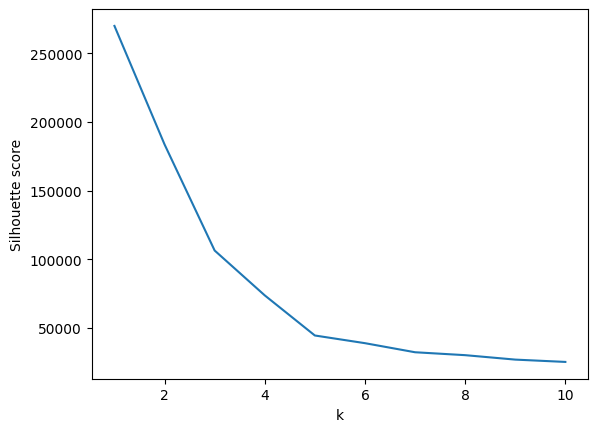

In [26]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init="k-means++",random_state=41)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.figure()
plt.plot(range(1, 11), wcss)
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.show

In [ ]:
from sklearn.metrics import silhouette_score
sil=[]
kmax=10
for k in range(2,kmax):
    KMeans = KMeans(n_clusters=k, random_state=42).fit(x)
    labels=kmeans.labels_
    sil.append(silhouette_score(x,labels))
    plt.figure()
    plt.plot(range(2,kmax),sil)
    plt.xlabel("k")
    plt.ylabel("Silhouette score")
    plt.show

In [ ]:
kmeans = KMeans(n_clusters=5,init='k-mean++',random_state=42)

## 1. Vue d'ensemble

In [5]:
print('Shape:', df.shape)
print('\nTypes des colonnes:')
print(df.dtypes)
print('\nValeurs manquantes:')
print(df.isnull().sum())

Shape: (200, 5)

Types des colonnes:
CustomerID                int64
Genre                       str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Valeurs manquantes:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2. Distribution des variables numériques

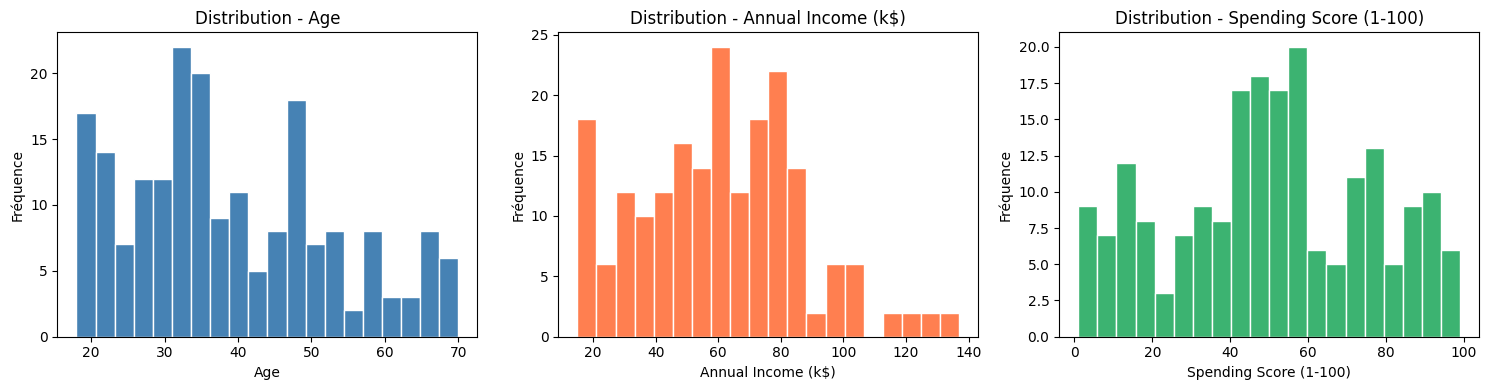

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, col, color in zip(axes, cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white')
    ax.set_title(f'Distribution - {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

## 3. Répartition par Genre

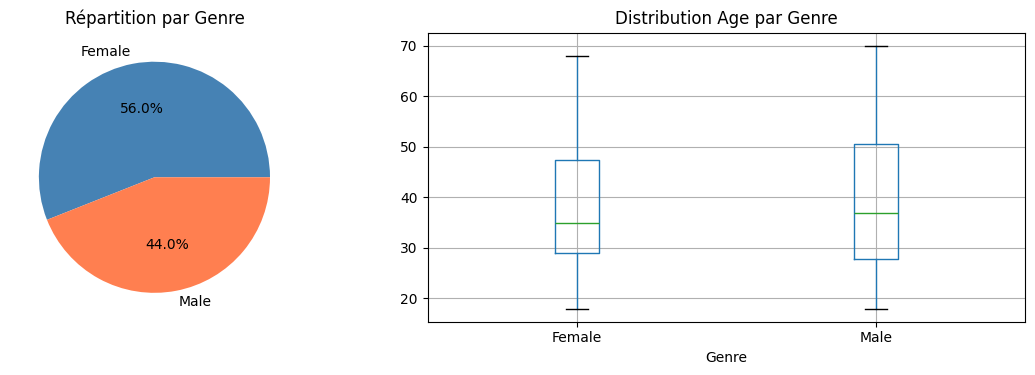

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

genre_counts = df['Genre'].value_counts()
axes[0].pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[0].set_title('Répartition par Genre')

df.boxplot(column='Age', by='Genre', ax=axes[1])
axes[1].set_title('Distribution Age par Genre')
axes[1].set_xlabel('Genre')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Matrice de corrélation

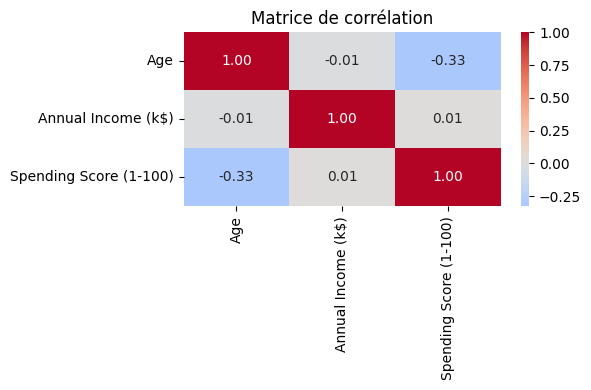

In [9]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

## 5. Scatter plots - Relations clés pour le clustering

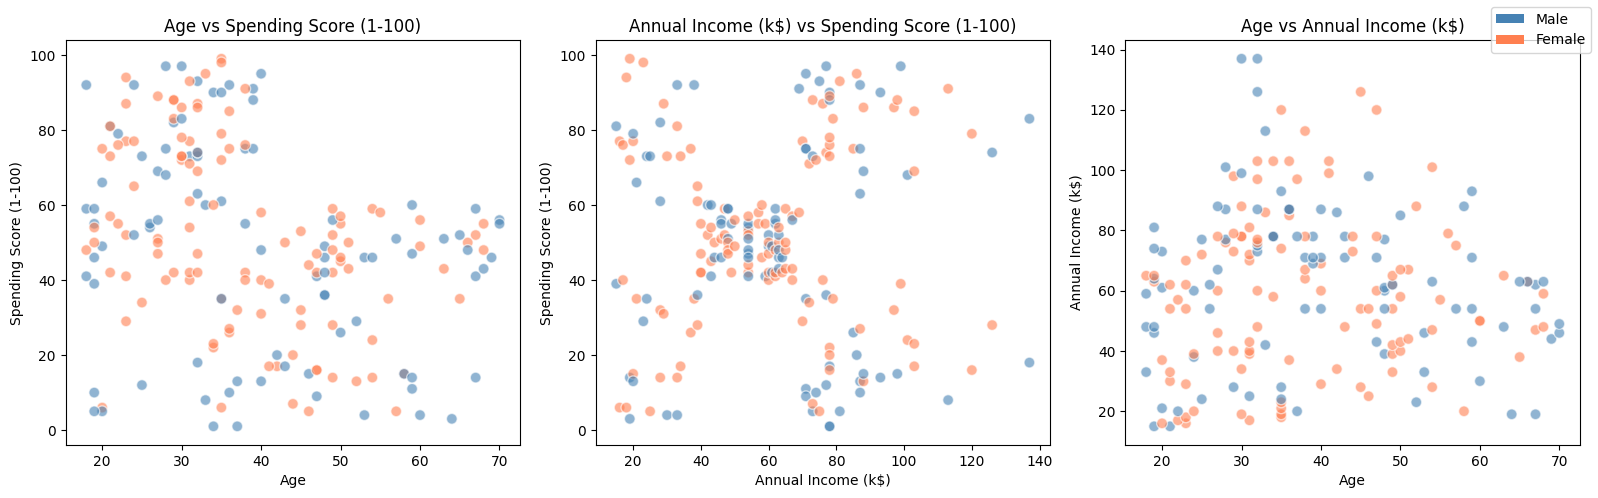

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [
    ('Age', 'Spending Score (1-100)'),
    ('Annual Income (k$)', 'Spending Score (1-100)'),
    ('Age', 'Annual Income (k$)')
]
colors_genre = df['Genre'].map({'Male': 'steelblue', 'Female': 'coral'})

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], c=colors_genre, alpha=0.6, edgecolors='white', s=60)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

legend_elements = [Patch(facecolor='steelblue', label='Male'), Patch(facecolor='coral', label='Female')]
fig.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

## 6. Méthode du Coude (Elbow Method) - Choix du K optimal

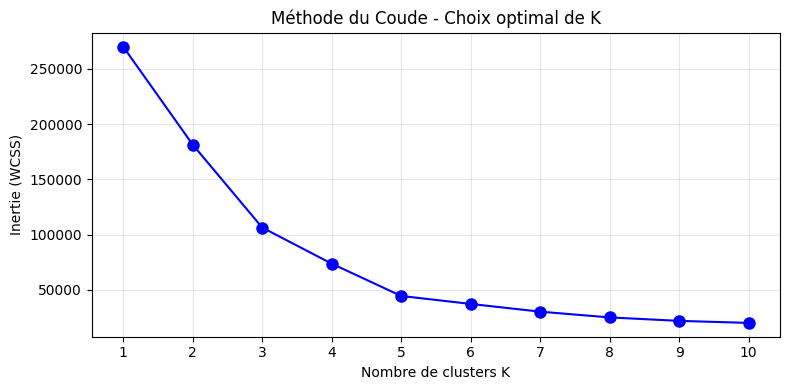

Le coude se situe autour de K=5 pour ce dataset.


In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie (WCSS)')
plt.title('Méthode du Coude - Choix optimal de K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Le coude se situe autour de K=5 pour ce dataset.')

## Conclusion
- 200 clients, aucune valeur manquante → dataset propre
- Variables clés pour le clustering : `Annual Income` et `Spending Score`
- Le scatter plot montre 5 groupes visuellement distincts
- La méthode du coude confirme **K=5** comme nombre optimal

➡️ Prochaine étape : appliquer K-Means avec K=5

In [27]:
kmeans = KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans = kmeans.fit_predict(x)

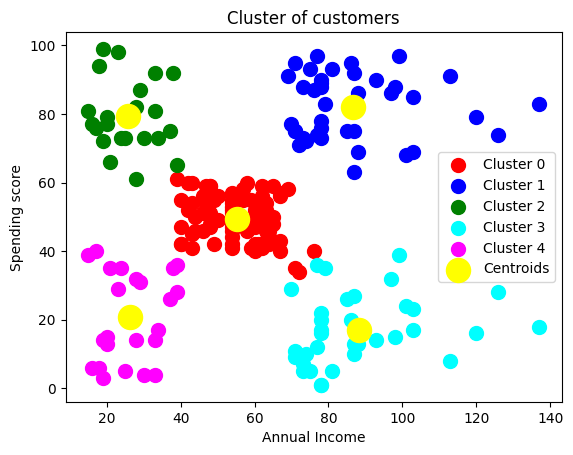

In [31]:
plt.scatter(x[y_kmeans==0,0],x[y_kmeans==0,1],s=100,c='red',label="Cluster 0")
plt.scatter(x[y_kmeans==1,0],x[y_kmeans==1,1],s=100,c='blue',label="Cluster 1")
plt.scatter(x[y_kmeans==2,0],x[y_kmeans==2,1],s=100,c='green',label="Cluster 2")
plt.scatter(x[y_kmeans==3,0],x[y_kmeans==3,1],s=100,c='cyan',label="Cluster 3")
plt.scatter(x[y_kmeans==4,0],x[y_kmeans==4,1],s=100,c='magenta',label="Cluster 4")
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='yellow',label="Centroids")
plt.xlabel('Annual Income')
plt.ylabel('Spending score')
plt.title('Cluster of customers')
plt.legend()
plt.show()

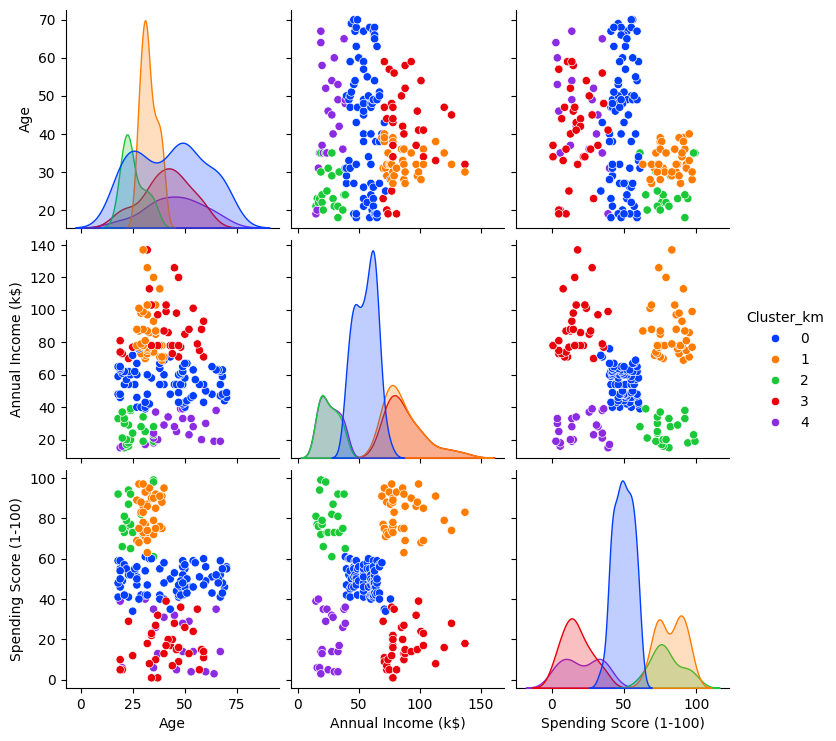

In [32]:
df["Cluster_km"] = kmeans.labels_
sns.pairplot(df,palette='bright',hue="Cluster_km")

In [35]:
#carateristiques des clusters
new = df.drop(["Genre"],axis=1)
display(new.groupby('Cluster_km').mean())

,Age,Annual Income (k$),Spending Score (1-100)
Cluster_km,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [37]:
len(df[df.Cluster_km == 3])
df[df.Cluster_km == 3]

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_km
124,Female,23,70,29,3
128,Male,59,71,11,3
130,Male,47,71,9,3
134,Male,20,73,5,3
136,Female,44,73,7,3
138,Male,19,74,10,3
140,Female,57,75,5,3
144,Male,25,77,12,3
146,Male,48,77,36,3
148,Female,34,78,22,3


<Axes: xlabel='Cluster_km', ylabel='count'>

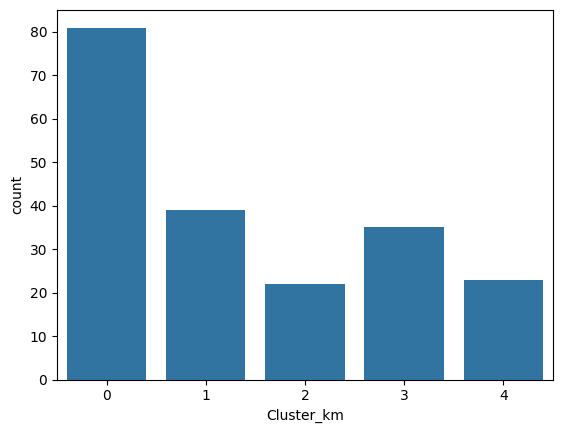

In [ ]:
sns.countplot(x="Cluster_km",data=df)
#essayer de faire le clustering avec age, annual income, spending score